# Project Title: A Growth-Based Financial Red Flag Screener for North American Apparel Retail Industry

## 1. Problem Definition and Intended User
**Problem:**
This analysis delivers an industry screening framework for the North American apparel retail sector. It helps beginner investors and business analytics students identify early operational divergence by comparing sales growth with inventory, fixed asset, and receivables expansion over recent fiscal years.

This notebook does not aim to prove fraud. It focuses on early risk signals where business expansion appears unsupported by sales growth, enabling users to prioritize companies for further due diligence.

**Intended User:** This tool is designed for beginner investors and business students who need a transparent, repeatable way to compare apparel retail peers and surface potential operational risk before making investment or research decisions.


## 2. Data Source and Sample
*   **Data Source:** WRDS (Compustat - Fundamentals Annual). 
*   **Date Accessed:** April 18, 2026
*   **Sample:** Full industry sample of North American apparel retail companies (SIC codes 5600-5699: Apparel and Accessory Stores). This represents a comprehensive analysis of the entire U.S. apparel retail sector rather than a selected subset of companies.
*   **Timeframe:** Fiscal years from 2018 to present.

# 3. Load and Clean Data

In [1]:

import wrds
import pandas as pd

# Connect to WRDS
db = wrds.Connection(wrds_username="your_username") 

# Parameterisation: Define industry SIC codes and start year
# SIC 5600-5699 covers Apparel and Accessory Stores (retail)
# In Compustat, the SIC field is 'sich' (historical SIC code)
sic_codes = "sich BETWEEN 5600 AND 5699"
start_year = 2018

# Parameterised SQL query with strict filters to ensure data quality
# Only industrial format to ensure consistent financial statement structure
# Only standard data format to avoid complications from different reporting styles
# Only domestic population source to focus on US companies
# Only consolidated data to get the full picture of company performance
# SIC codes define the full industry sample for apparel retail

sql_query = f"""
    SELECT tic, fyear, sale, invt, ppent, rect
    FROM comp.funda
    WHERE {sic_codes}
    AND fyear >= {start_year}
    AND indfmt = 'INDL' 
    AND datafmt = 'STD' 
    AND popsrc = 'D' 
    AND consol = 'C'
"""

# Execute query
df = db.raw_sql(sql_query)

# Data Cleaning: Remove duplicates and rows with missing core metrics
df = df.drop_duplicates(subset=['tic', 'fyear'])
df = df.dropna(subset=['sale', 'invt', 'ppent', 'rect'])

# Sort values to ensure accurate growth rate calculations later
df = df.sort_values(by=['tic', 'fyear'])
print("Sample data")
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Sample data
       tic  fyear      sale     invt     ppent     rect
26   0190A   2018  2483.994   390.47    243.62   47.673
21     AEO   2018   4035.72  424.404   742.149   93.477
54     AEO   2019  4308.212  446.278  2154.036  119.064
82     AEO   2020  3759.113  405.445  1779.773  146.102
106    AEO   2021  5010.785  553.458  1921.293  286.683


## 4. Substantive Python Analysis: Calculate Growth Rates and Apply Warning Rules

In this section, Pandas `pct_change()` is used to calculate the year-on-year growth rates of the four key variables: sales, inventory, fixed assets, and accounts receivable.

**Red Flag Rules:**  
The screening logic compares the growth of inventory, fixed assets, and accounts receivable with sales growth.

- **Flag 1 (Inventory Warning):** Inventory Growth − Sales Growth > 15%  
- **Flag 2 (Fixed Asset Warning):** Fixed Assets Growth − Sales Growth > 15%  
- **Flag 3 (Receivables Warning):** Accounts Receivable Growth − Sales Growth > 20%  

A Python function is then used to check these conditions for each company-year observation and assign a **Warning Count** from 0 to 3.

### 4.1 Calculate Year-over-Year (YoY) Growth Rates

In [2]:
# Use groupby('tic') to ensure calculations remain strictly within each company.
# pct_change() automatically computes the percentage change between the current and prior row.
df['sale_gr'] = df.groupby('tic')['sale'].pct_change()
df['invt_gr'] = df.groupby('tic')['invt'].pct_change()
df['ppent_gr'] = df.groupby('tic')['ppent'].pct_change()
df['rect_gr'] = df.groupby('tic')['rect'].pct_change()

# Review the data to confirm the calculation
# The first year (2018) for each company will show 'NaN' (Not a Number) 
# because there is no 2017 data to compare it against.
print("Growth Rates Calcula ted:")
display(df[['tic', 'fyear', 'sale_gr', 'invt_gr', 'ppent_gr', 'rect_gr']].head(10))

Growth Rates Calcula ted:


,tic,fyear,sale_gr,invt_gr,ppent_gr,rect_gr
26,0190A,2018,<NA>,<NA>,<NA>,<NA>
21,AEO,2018,<NA>,<NA>,<NA>,<NA>
54,AEO,2019,0.06752,0.051541,1.902431,0.273725
82,AEO,2020,-0.127454,-0.091497,-0.17375,0.227088
106,AEO,2021,0.33297,0.365063,0.079516,0.962211
131,AEO,2022,-0.004181,0.057141,-0.027471,-0.154516
155,AEO,2023,0.054498,0.094993,-0.080216,0.022889
179,AEO,2024,0.012711,-0.006254,0.19087,0.058205
193,AEO,2025,0.041021,0.102585,0.108641,-0.014259
23,ANF,2018,<NA>,<NA>,<NA>,<NA>


### 4.2 Apply Red Flag Warning Rules

In [3]:
def calculate_warning_score(row):
    """
    Evaluates growth rate disparities based on specific thresholds.
    Returns a score from 0 to 3 based on how many red flags are triggered.
    """
    # Skip the first year (NaN) since growth rates cannot be calculated
    if pd.isna(row['sale_gr']):
        return 0
    
    warnings = 0
    
    # Flag 1: Inventory Growth − Sales Growth > 15%
    if (row['invt_gr'] - row['sale_gr']) > 0.15:
        warnings += 1
        
    # Flag 2: Fixed Assets Growth − Sales Growth > 15%
    if (row['ppent_gr'] - row['sale_gr']) > 0.15:
        warnings += 1
        
    # Flag 3: Accounts Receivable Growth − Sales Growth > 20%
    if (row['rect_gr'] - row['sale_gr']) > 0.20:
        warnings += 1
        
    return warnings

# Apply the custom function row by row (axis=1)
df['warning_score'] = df.apply(calculate_warning_score, axis=1)

# Drop the first year (NaN values) to only show meaningful analysis years
analysis_df = df.dropna(subset=['sale_gr']).copy()

# Sort by warning score to see the most concerning company-years at the top
analysis_df = analysis_df.sort_values(by='warning_score', ascending=False)

print("=== Top Company-Years with Highest Warning Scores ===")
display(analysis_df[['tic', 'fyear', 'sale_gr', 'invt_gr', 'ppent_gr', 'rect_gr', 'warning_score']].head(20))

=== Top Company-Years with Highest Warning Scores ===


,tic,fyear,sale_gr,invt_gr,ppent_gr,rect_gr,warning_score
136,ZUMZ,2022,-0.190466,0.047356,-0.017573,0.428779,3
89,EXPRQ,2020,-0.401556,0.199984,-0.222926,8.107205,3
80,CHS,2020,-0.350279,-0.173278,-0.141472,2.437436,3
75,BURL,2020,-0.20894,-0.046909,0.028404,2.080179,3
70,JWN,2020,-0.309778,-0.029687,-0.107509,3.497207,3
54,AEO,2019,0.06752,0.051541,1.902431,0.273725,2
39,JWN,2019,-0.021185,-0.029323,0.518235,0.209459,2
135,PLCE,2022,-0.108012,0.044266,-0.126706,1.267941,2
86,PLCE,2020,-0.186067,0.186377,-0.262071,0.204864,2
43,DXLG,2019,0.000595,-0.041343,1.860762,0.407014,2


# 5. Data Visualisation


### 5.1 Identifying the Outliers
Before diving into the operational dynamics of specific firms, we first aggregate the total **Warning Scores** accumulated by each company across the entire analyzed period. This macro-level view helps us immediately identify the most concerning outliers in the industry. As highlighted in red below, the top three firms with the highest cumulative flags will be selected for deeper visual inspection.

In [4]:
%pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


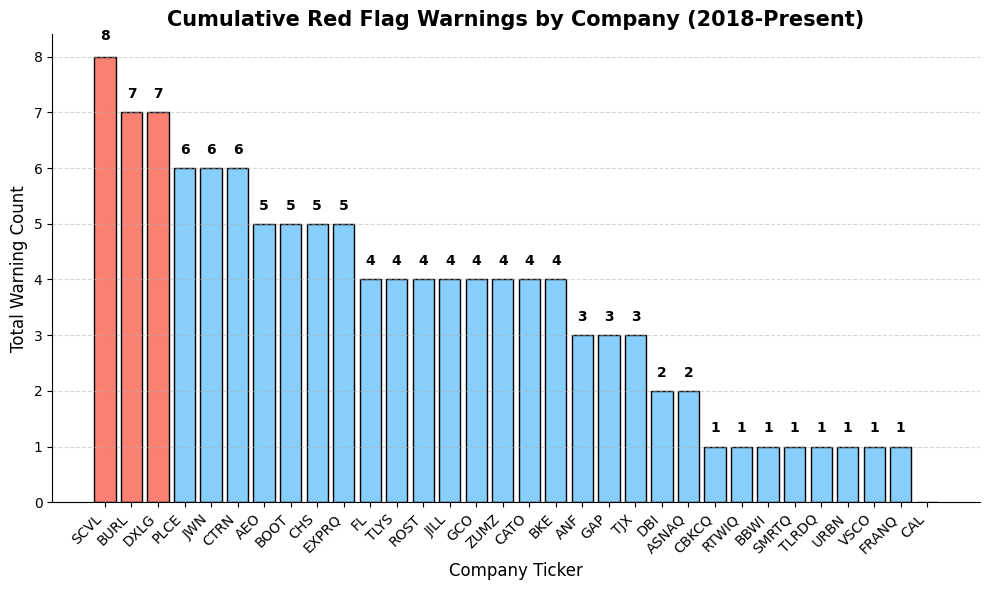

In [5]:

import matplotlib.pyplot as plt

# 1. Calculate total warning score for each company by summing across all years
risk_summary = analysis_df.groupby('tic')['warning_score'].sum().sort_values(ascending=False)

# 2. Set up the figure size for better readability
plt.figure(figsize=(10, 6))

# 3. Plot the bar chart (default color is a soft blue)
bars = plt.bar(risk_summary.index, risk_summary.values, color='#87CEFA', edgecolor='black')

# 4. Visually highlight the top 3 companies with the highest cumulative warning scores in a soft warning red color
for i in range(min(3, len(bars))): 
    bars[i].set_color('#FA8072') #  (Salmon)
    bars[i].set_edgecolor('black')

# 5. Add title and axis labels with enhanced font styling for better aesthetics
plt.title('Cumulative Red Flag Warnings by Company (2018-Present)', fontsize=15, fontweight='bold')
plt.xlabel('Company Ticker', fontsize=12)
plt.ylabel('Total Warning Count', fontsize=12)

# Rotate x-axis labels to prevent overlapping
plt.xticks(rotation=45, ha='right')

# 6. Add data labels on top of each bar to show the exact warning count, but only if it's greater than 0 to keep the chart clean
for bar in bars:
    yval = bar.get_height()
    # Only show the data label if the warning count is greater than 0 to avoid cluttering the chart with zeros
    if yval > 0:
        # Position labels closer to the bar top to reduce vertical whitespace
        label_offset = max(0.2, yval * 0.03)  # Minimum 0.2, or 3% of bar height for taller bars
        plt.text(bar.get_x() + bar.get_width()/2, yval + label_offset, int(yval), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', 
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

# 7. Aesthetic adjustments: Remove top and right spines for a cleaner look, and add grid lines for better readability
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
# Display top 3 companies for documentation update
print("Top 3 High-Risk Companies in Full Industry Analysis:")
print(risk_summary.head(3))

Top 3 High-Risk Companies in Full Industry Analysis:
tic
SCVL    8
BURL    7
DXLG    7
Name: warning_score, dtype: int64


### 5.2 Deep Dive: Visualizing Operational Divergence

This section takes a closer look at the three companies with the highest warning scores.

The charts show how **inventory**, **fixed assets**, and **receivables** growth compare with **sales growth**. When these indicators rise much faster than sales, it may be a warning sign. This helps identify which metric triggered the red flag and when the divergence was most obvious.

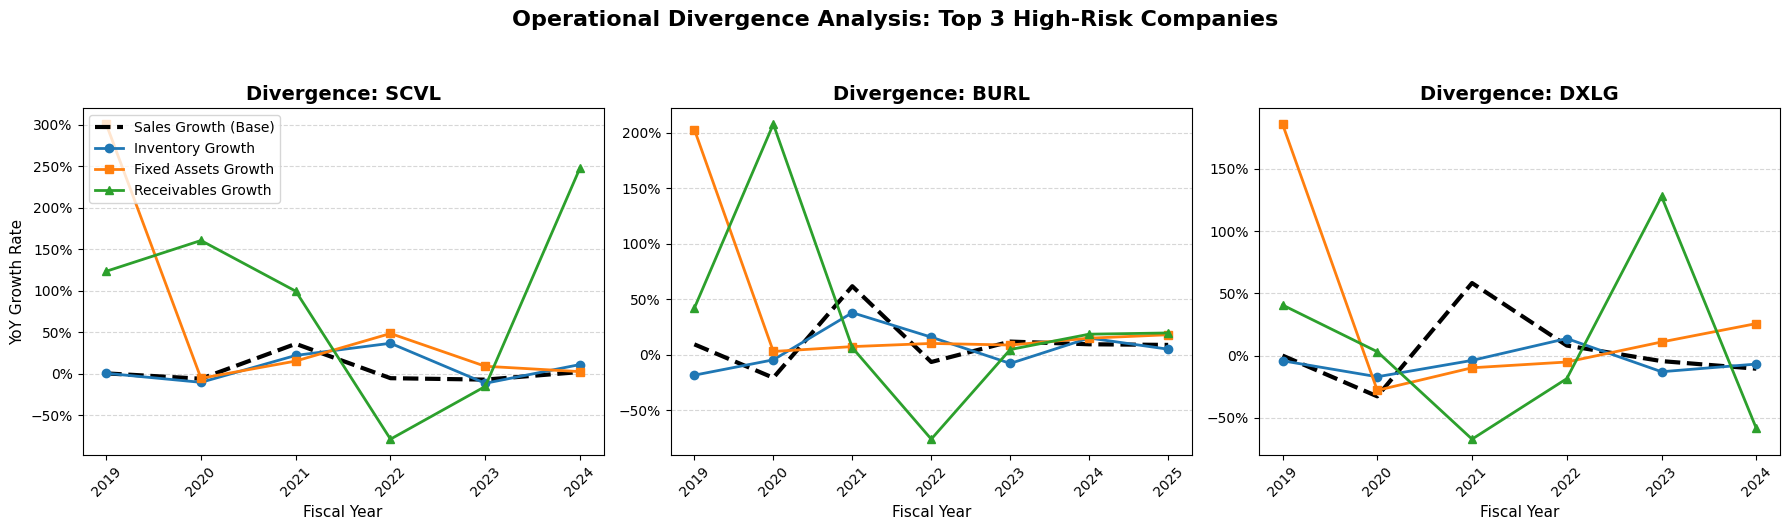

In [7]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Identify the top 3 companies with the highest cumulative warning scores for deeper analysis
top_3_to_analyze = risk_summary.index[:3]

# 2. Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ticker in enumerate(top_3_to_analyze):
    ax = axes[i]
    df_ticker = analysis_df[analysis_df['tic'] == ticker].copy()
    
    # Sort by year to ensure correct x-axis order
    df_ticker = df_ticker.sort_values(by='fyear')
    
    # Create numeric x-axis positions and year labels to avoid sorting issues
    x_positions = range(len(df_ticker))
    year_labels = df_ticker['fyear'].astype(int).astype(str).values
    
    # Plot the lines using numeric positions
    ax.plot(x_positions, df_ticker['sale_gr'].values, label='Sales Growth (Base)', color='black', linewidth=3, linestyle='--')
    ax.plot(x_positions, df_ticker['invt_gr'].values, label='Inventory Growth', marker='o', linewidth=2)
    ax.plot(x_positions, df_ticker['ppent_gr'].values, label='Fixed Assets Growth', marker='s', linewidth=2)
    ax.plot(x_positions, df_ticker['rect_gr'].values, label='Receivables Growth', marker='^', linewidth=2)
    
    # Set x-axis labels and positions
    ax.set_xticks(x_positions)
    ax.set_xticklabels(year_labels, rotation=45)
    
    # title and labels
    ax.set_title(f'Divergence: {ticker}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fiscal Year', fontsize=11)
    
    # add Y-axis formatting and grid lines for better readability
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Only add Y-axis label and legend to the first subplot for a cleaner look
    if i == 0:
        ax.set_ylabel('YoY Growth Rate', fontsize=11)
        ax.legend(loc='upper left', fontsize=10, frameon=True)

# 4. Add a main title for the entire figure and adjust layout for better aesthetics
plt.suptitle('Operational Divergence Analysis: Top 3 High-Risk Companies', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Close database connection after all analysis is complete
db.close()

## 6. Interpretation and Findings

### Key Results

In this comprehensive industry analysis covering all apparel and accessory retail companies (SIC codes 5600-5699), three companies stand out as outliers: **SCVL**, **BURL**, and **DXLG** showed the highest cumulative warning scores across the analyzed period.

The primary drivers of these warnings were:
- Inventory levels growing significantly faster than sales
- Fixed asset investments expanding beyond revenue growth
- Accounts receivable accumulating disproportionately to sales

---

### What the Data Visualizations Reveal

**Figure 5.1 (Cumulative Risk Overview):**
This bar chart provides an immediate snapshot of the entire apparel retail industry: which companies accumulated the most warning signals over the study period. Companies with higher bars suggest a pattern rather than an isolated event—repeated years with growth misalignment warrant attention. The analysis covers the full SIC 5600-5699 sector, providing a comprehensive view of industry-wide risk patterns.

**Figure 5.2 (Year-by-Year Divergence Patterns):**
The three trend charts zoom into the specific years and metrics driving concern for the highest-risk companies. For each high-risk company, you can see when inventory, fixed assets, or receivables spiked relative to sales. Some divergences appear temporary (single-year anomalies), while others persist across multiple years, suggesting systemic operational or strategic shifts rather than one-off occurrences. The comparison between the three companies also reveals different risk profiles—for instance, one company might struggle with inventory buildup while another faces receivables management issues.

---

### Conclusion

**Practical Takeaway:**
This comprehensive industry screener successfully identifies companies whose operational metrics diverge from growth trajectories across the entire apparel retail sector. Rather than flagging definitive fraud or mismanagement, it surfaces companies worthy of deeper investigation. For beginner investors and analysts, the tool cuts through noise by focusing on a simple, interpretable metric: when business expansion (measured by assets and inventory) outpaces revenue, it raises questions worth asking.

**Industry-Wide Insights:**
The analysis of all SIC 5600-5699 apparel retail companies reveals that while most firms maintain reasonable alignment between operational metrics and sales growth, a small subset consistently shows concerning patterns. This suggests that operational discipline varies significantly within the industry, with some companies demonstrating better control over inventory and asset management than others.

**Next Steps for Investors:**
1. Use this screening tool to build an initial watchlist from the comprehensive industry analysis
2. For flagged companies, cross-reference SEC filings to understand *why* these divergences occurred (e.g., is it intentional capacity building for anticipated growth, or operational stress?)
3. Combine with qualitative analysis—management commentary, industry trends, competitive positioning—to inform investment decisions
4. Consider sector rotation strategies based on which sub-sectors within apparel retail show better operational discipline

**For Practitioners:**
This framework is extensible and now covers the entire apparel retail industry. Users can adjust thresholds (currently 15% and 20%) based on industry norms, refine the analysis by sub-sector within SIC 5600-5699, or incorporate additional metrics (e.g., cash flow, operating efficiency) for more nuanced screening. The comprehensive industry coverage provides better benchmarking and risk assessment capabilities.

---

### Limitations

1. **Statistical Anomalies ≠ Red Flags:** The tool identifies unusual patterns in financial metrics, not definitive proof of problems. Rapid growth, acquisitions, or supply chain disruptions can legitimately cause these divergences.

2. **Industry Scope and Generalization:** While this analysis covers the entire apparel and accessory retail sector (SIC codes 5600-5699), results may not generalize to other retail sub-sectors or different industries with different operational dynamics.

3. **Time-Specific Context Matters:** The 2018–present window captures COVID-era supply chain chaos, e-commerce acceleration, and post-pandemic restructuring—all of which inflated asset and inventory levels industry-wide. Historical thresholds may need adjustment for different periods.

4. **Requires Qualitative Follow-Up:** Red flags are starting points, not conclusions. SEC filings, earnings calls, and industry reports must accompany this quantitative screening for informed decision-making.

5. **Data Classification and Timing:** Significant growth spikes in specific years may reflect legitimate operational events such as acquisitions, store expansion, capital restructuring, or accounting reclassifications rather than financial anomalies. Users should validate findings against raw financial data and management commentary to understand the drivers.

6. **Peer Group Comparability:** The comprehensive industry analysis includes companies of varying sizes and business models within apparel retail. Some flagged companies may be outliers due to their specific business strategies (e.g., fast-fashion vs. luxury retail) rather than operational issues.

7. **Threshold Sensitivity:** The 15% and 20% growth divergence thresholds are rule-of-thumb guidelines. Different sub-sectors within apparel retail may require different thresholds based on their typical growth patterns and capital intensity.